### Step 1: Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input 

### Step 2: Load Data using ImageDataGenerator

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,                            
    brightness_range=[0.8, 1.2],               
    width_shift_range=0.1,
    height_shift_range=0.1,
)


val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "IMAGES",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    "IMAGES",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False  
)

print(train_data.class_indices)
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.
{'0_fake': 0, '1_real': 1}
Training samples: 6400
Validation samples: 1600


### Step 3: Build Model (Transfer Learning + Fine-Tuning)

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = False


for layer in base_model.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization): 
        layer.trainable = True


x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)


model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers: {trainable_count} / {len(model.layers)}")
model.summary()

Trainable layers: 26 / 161


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 1,874,241 (7.15 MB)

 Non-trainable params: 749,824 (2.86 MB)

### Step 4: Train Model

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',   
    patience=5,               
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,         
    callbacks=[early_stop, reduce_lr, checkpoint]
)

C:\Users\admin\.conda\envs\datasci\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5423 - loss: 0.7945  
Epoch 1: val_accuracy improved from None to 0.61250, saving model to best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 476s 2s/step - accuracy: 0.5589 - loss: 0.7409 - val_accuracy: 0.6125 - val_loss: 0.6681 - learning_rate: 1.0000e-04
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5971 - loss: 0.6718  
Epoch 2: val_accuracy improved from 0.61250 to 0.61875, saving model to best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.6062 - loss: 0.6612 - val_accuracy: 0.6187 - val_loss: 0.6952 - learning_rate: 1.0000e-04
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6394 - loss: 0.6379  
Epoch 3: val_accuracy improved from 0.61875 to 0.69063, saving model to best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.6470 - loss: 0.6274 - val_accuracy: 0.6906 - val_loss: 0.5851 - learning_rate: 1.0000e-04
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━

### Step 5: Plot Training History

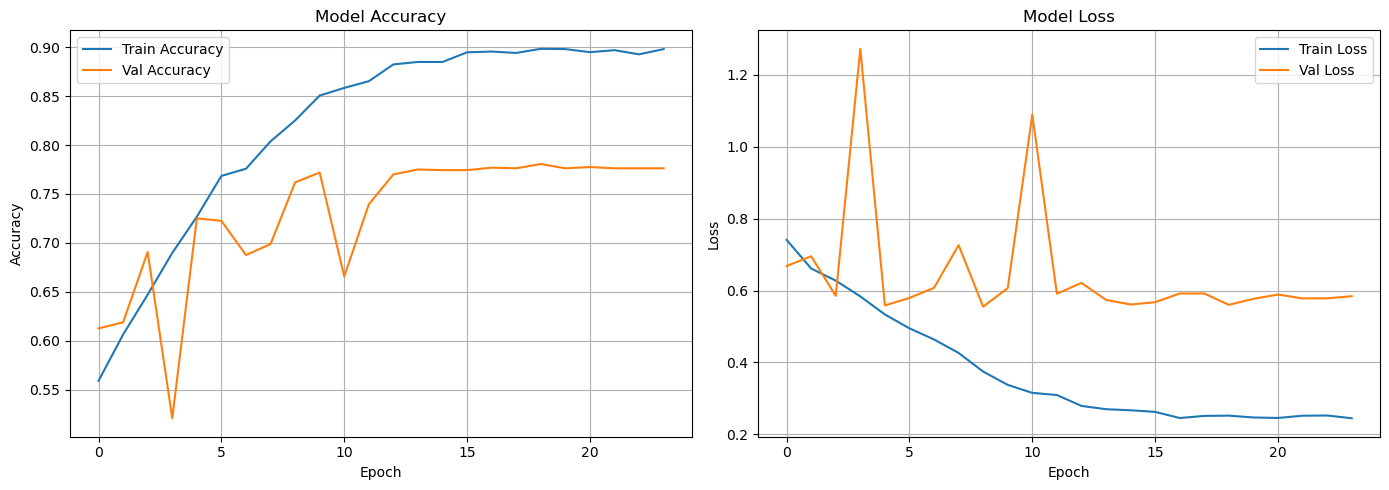

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Step 6: Evaluate Model

In [6]:
loss, accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Loss: {loss:.4f}")

#  classification report
val_data.reset()
y_pred_probs = model.predict(val_data)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_data.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(val_data.class_indices.keys())))

50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 972ms/step - accuracy: 0.7806 - loss: 0.5601
Validation Accuracy: 0.7806
Validation Loss: 0.5601
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 962ms/step

Classification Report:
              precision    recall  f1-score   support

      0_fake       0.80      0.74      0.77       800
      1_real       0.76      0.82      0.79       800

    accuracy                           0.78      1600
   macro avg       0.78      0.78      0.78      1600
weighted avg       0.78      0.78      0.78      1600



### Step 7: Save Model

In [7]:
model.save('fake_image_detector.keras')
print(" Model saved as 'fake_image_detector.keras'")

# To reload later:
# from tensorflow.keras.models import load_model
# model = load_model('fake_image_detector.keras')

 Model saved as 'fake_image_detector.keras'


### Step 8: Test on New Image

In [8]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def predict_image(path):
    img = cv2.imread(path)

    if img is None:
        print(" Error: Image not found or unsupported format")
        return

    # Convert BGR (cv2 default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224, 224))

    img = preprocess_input(img.astype(np.float32))
    img = np.reshape(img, (1, 224, 224, 3))

    prediction = model.predict(img)[0][0]

    print(f"Prediction Score: {prediction:.4f}")

    if prediction > 0.5:
        print(f" Real Image  (confidence: {prediction*100:.1f}%)")
    else:
        print(f" Fake Image  (confidence: {(1-prediction)*100:.1f}%)")

In [19]:
# Example usage:
predict_image("IMAGES/1_real/0.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Prediction Score: 0.8498
 Real Image  (confidence: 85.0%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Prediction Score: 0.0191
 Fake Image  (confidence: 98.1%)
